# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [147]:
# Installing the Python libraries with the specified version, to ensure proper running and avoid the compatability issues while carrying out the data analysis and visualition.

!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [1]:
# import the necessary libraries for data manipulation
import numpy as np
import pandas as pd

# import the neccessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
# The foodhub_order dataset is saved in the Google Drive for further analysis. It is read using the pandas and loaded in the dataframe 'df'. For a preview, the display command is used.
df = pd.read_csv('/content/drive/MyDrive/Great_Learning_AI_ML_Projects/foodhub_order.csv')
display(df)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [5]:
# To view the first five records, use the method .head(). By default, this method displays the first five records.
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
#The attribute .shape  of a respective dataframe  will provide total number of rows and columns in the output. The number of rows = 1898 and columns = 9
df.shape

(1898, 9)

#### Observations:  The number of rows = 1898 and columns = 9


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# To identify the different datatypes in a dataset, use the function info()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:  Food Hub dataset has integer, float and object data types


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# To check and identify the missing values in the dataset.
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:  As observed there is no missing values, so no treatment is required.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# The statistical summary of the dataset
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [11]:
#the minimum, average, and maximum time it takes for food to be prepared once an order is placed
min_time = df['food_preparation_time'].min()
print("The minimum time it takes for food to be prepared once an order is placed is : ",min_time,"minutes")

avg_time = df['food_preparation_time'].mean()
print("The average time it takes for food to be prepared once an order is placed is : ",int(avg_time),"minutes")

max_time = df['food_preparation_time'].max()
print("The maximum time it takes for food to be prepared once an order is placed is : ",max_time,"minutes")


The minimum time it takes for food to be prepared once an order is placed is :  20 minutes
The average time it takes for food to be prepared once an order is placed is :  27 minutes
The maximum time it takes for food to be prepared once an order is placed is :  35 minutes


#### Observations:

The minimum time it takes for food to be prepared once an order is placed is 20
minutes. This indicates that, some restaurants are very efficient and organised.
The average (mean) preparation time is 27 minutes, showing that most restaurants take around half an hour to prepare an order.
The maximum preparation time recorded is 35 minutes, which could point to some restaurants or dishes requiring more complex preparation or handling.





### **Question 5:** How many orders are not rated? [1 mark]

In [12]:
#displaying first five rows of rating column
df['rating'].head()

,rating
0,Not given
1,Not given
2,5
3,3
4,4


In [13]:
# Extracting the unique values present in the rating column.
print(df['rating'].unique())

['Not given' '5' '3' '4']


In [14]:
#To identify the counts of unique rating values
print(df['rating'].value_counts())

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64


In [15]:
#To know the number of orders not rated
not_rated = df['rating'].value_counts().iloc[0]
print("The number of orders not rated is : ",not_rated)

The number of orders not rated is :  736


#### Observations: Out of the total number of orders, 736 orders were not rated by the customers. This suggests that a significant portion of customers chose not to provide feedback. Offerinig the reward points by encouraging customers to rate their orders could help improve their process and service quality.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [16]:
# Identifying the list of categorical (obect type) and numerical(int, float) columns in the dataset to explore and plot
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [17]:
#creating a list for both categorical and numerical columns to use later
numeric_cols = ['order_id', 'customer_id', 'cost_of_the_order','food_preparation_time', 'delivery_time']

categorical_cols= ['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']

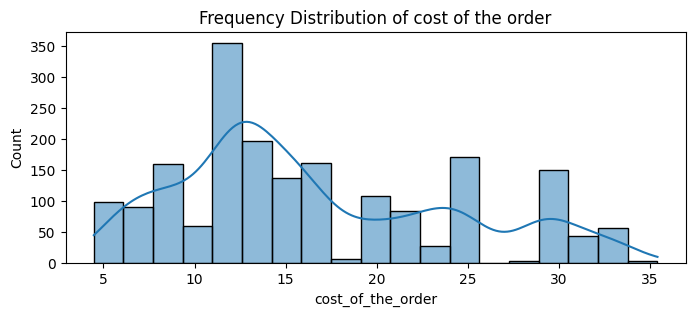

1. From the histogram, the cost of the order seems to be right skewed and most orders are low cost and peak mode is in between 5-10 dollars.


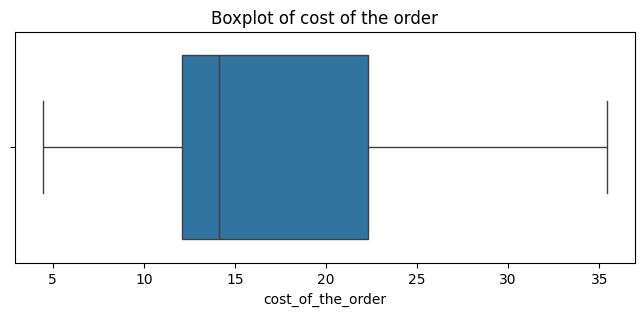

2. From the boxplot, there are some outliers, they tend to be high value orders. Overall the distribution is right skewed. 


In [18]:
#Ploting the histogram - for Count vs cost_of_the_order
plt.figure(figsize=(8,3))
sns.histplot(df['cost_of_the_order'], kde = True)
plt.title("Frequency Distribution of cost of the order")
plt.show()
print("1. From the histogram, the cost of the order seems to be right skewed and most orders are low cost and peak mode is in between 5-10 dollars.")

#Boxploting - for cost_of_the_order
plt.figure(figsize=(8,3))
sns.boxplot(x=df['cost_of_the_order'])
plt.title("Boxplot of cost of the order")
plt.show()
print("2. From the boxplot, there are some outliers, they tend to be high value orders. Overall the distribution is right skewed. ")



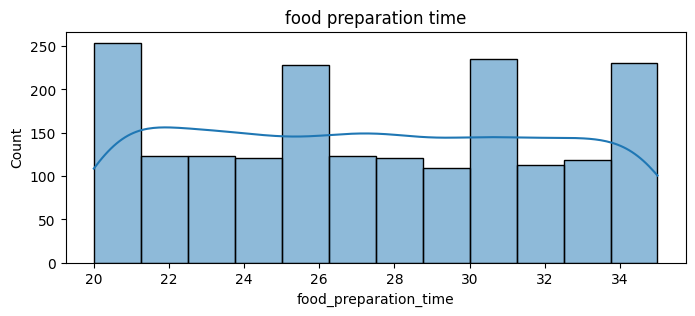

1. From the histogram, it appears to be bell-shaped distribution. most restaurants took 22 - 30 minutes to prepare food


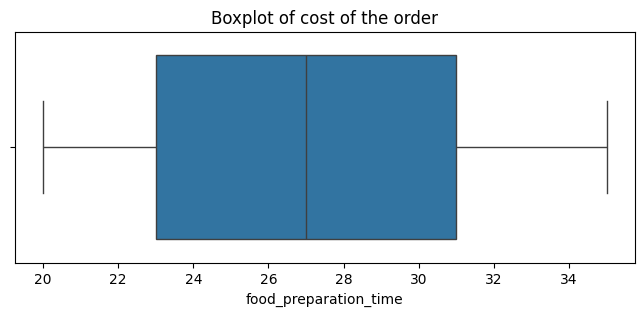

2. From the boxplot, the processing time is concentrated between 22-30 minutes. Also there are some outliers, may be some bottlenecks in processing. This can be improved. 


In [19]:
#Ploting the histogram - for Count vs cost_of_the_order
plt.figure(figsize=(8,3))
sns.histplot(df['food_preparation_time'], kde = True)
plt.title("food preparation time")
plt.show()
print("1. From the histogram, it appears to be bell-shaped distribution. most restaurants took 22 - 30 minutes to prepare food")

#Boxploting - for cost_of_the_order
plt.figure(figsize=(8,3))
sns.boxplot(x=df['food_preparation_time'])
plt.title("Boxplot of cost of the order")
plt.show()
print("2. From the boxplot, the processing time is concentrated between 22-30 minutes. Also there are some outliers, may be some bottlenecks in processing. This can be improved. ")



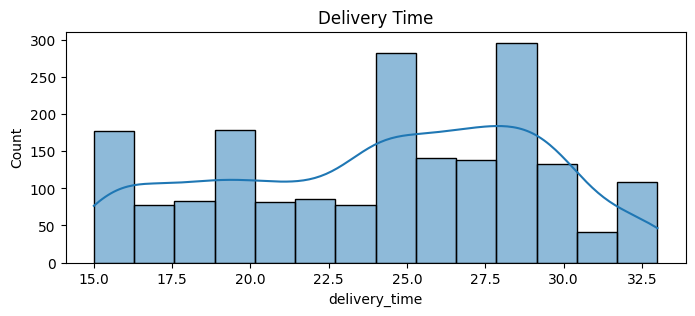

1. From the histogram, it appears most deliveries take 20-30  minutes, some of them took more than half an hour.


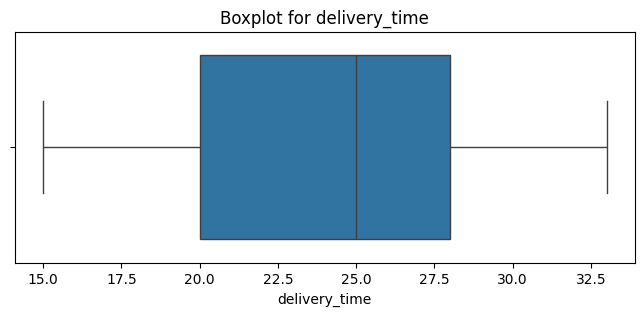

2. From the boxplot, the delivery time is in between 20-30 minutes. Also there are some outliers. From the insights, the restaurant staff can optimize the process to do quick delivery.


In [20]:
#Ploting the histogram - for Count vs cost_of_the_order
plt.figure(figsize=(8,3))
sns.histplot(df['delivery_time'], kde = True)
plt.title("Delivery Time")
plt.show()
print("1. From the histogram, it appears most deliveries take 20-30  minutes, some of them took more than half an hour.")

#Boxploting - for cost_of_the_order
plt.figure(figsize=(8,3))
sns.boxplot(x=df['delivery_time'])
plt.title("Boxplot for delivery_time")
plt.show()
print("2. From the boxplot, the delivery time is in between 20-30 minutes. Also there are some outliers. From the insights, the restaurant staff can optimize the process to do quick delivery.")


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


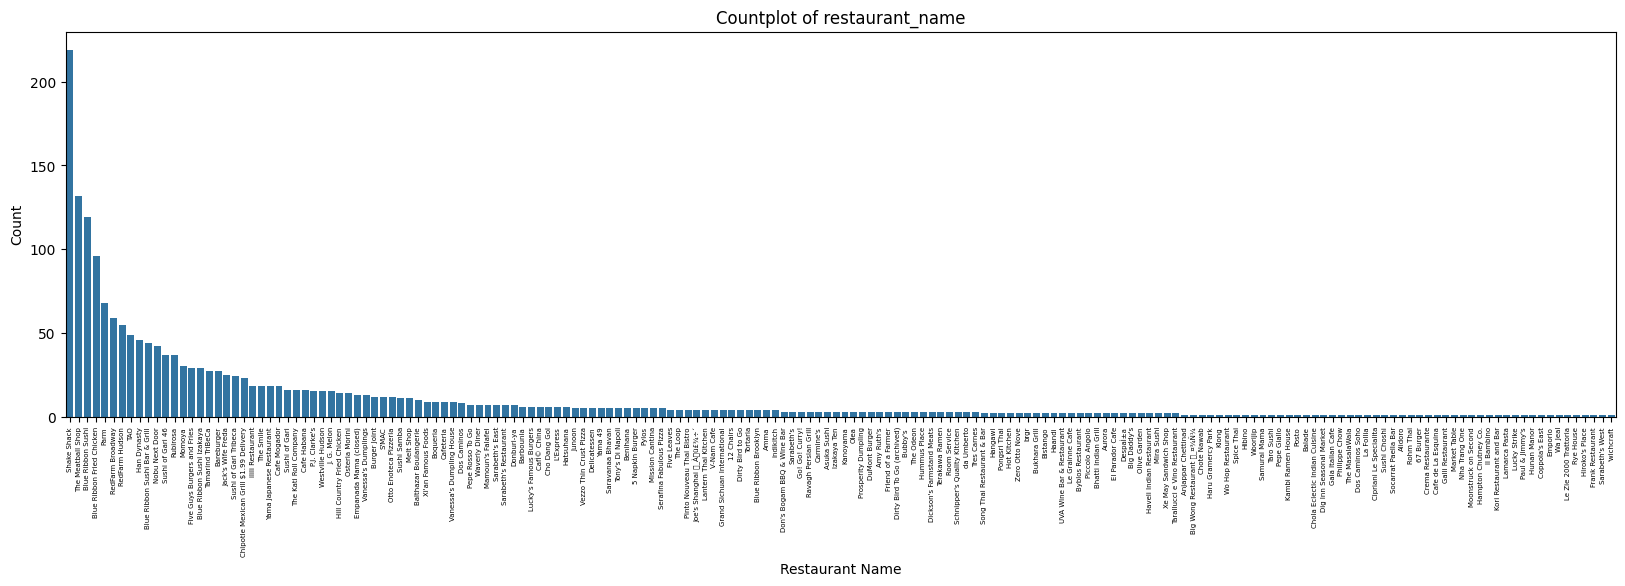

1. From the countplot, few restaurants (the left -most bars) have high orders, which means they are popular with good service.


In [21]:
#Ploting the countplot - for Count vs restaurant_name

plt.figure(figsize=(20,5))
sns.countplot(x=df['restaurant_name'], order=df['restaurant_name'].value_counts().index)
plt.title('Countplot of restaurant_name')
plt.xlabel('Restaurant Name')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=5)

plt.show()
print("1. From the countplot, few restaurants (the left -most bars) have high orders, which means they are popular with good service.")


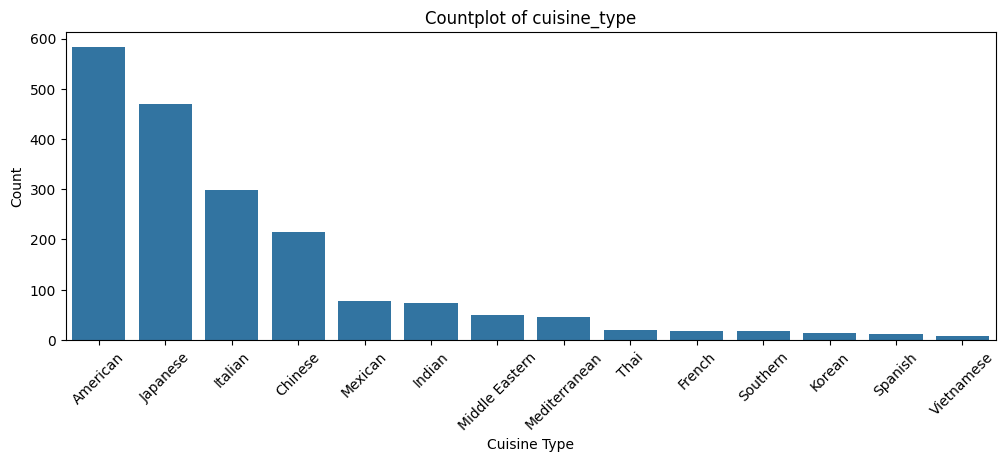

1. From the countplot, The american and japanese  cuisines are more popular among the customers. Less popular are Spanish and vietnamese.


In [22]:
#Ploting the countplot - for Count vs cuisine_type

plt.figure(figsize=(12,4))
sns.countplot(x=df['cuisine_type'], order=df['cuisine_type'].value_counts().index)
plt.title('Countplot of cuisine_type')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=45, fontsize=10)
plt.show()
print("1. From the countplot, The american and japanese  cuisines are more popular among the customers. Less popular are Spanish and vietnamese.")


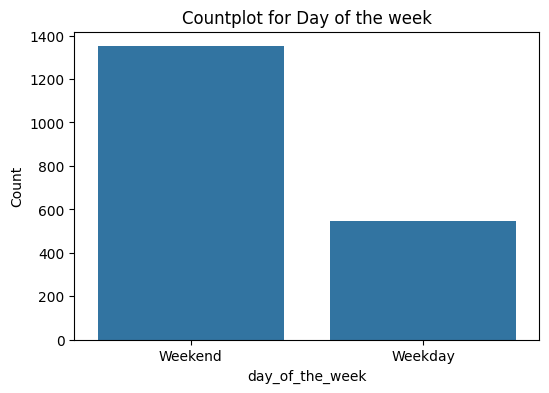

1. From the countplot, The restaurants served, almost 600 more orders on the weekend, compared to the weekday. Increasing the staff during the weekend can help processing the orders quickly.


In [23]:
#Ploting the countplot - for Count vs day_of_the_week

plt.figure(figsize=(6,4))
sns.countplot(x=df['day_of_the_week'], order=df['day_of_the_week'].value_counts().index)
plt.title('Countplot for Day of the week')
plt.xlabel('day_of_the_week')
plt.ylabel('Count')
plt.xticks(rotation=0, fontsize=10)
plt.show()
print("1. From the countplot, The restaurants served, almost 600 more orders on the weekend, compared to the weekday. Increasing the staff during the weekend can help processing the orders quickly.")

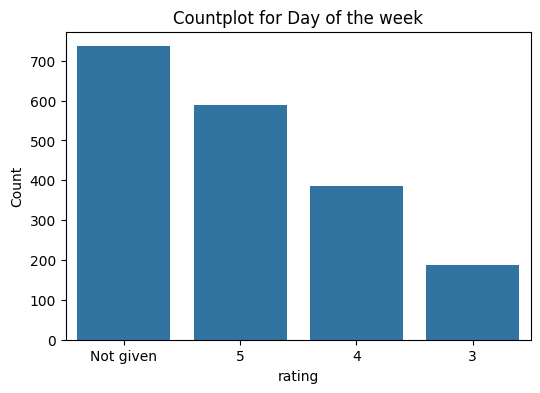

1. From the countplot, The customers often skip the rating orders. Among the rated orders there might be a skew towards positive(4-5) or negative (1-2) ratings.


In [24]:
#Ploting the countplot - for Count vs rating

plt.figure(figsize=(6,4))
sns.countplot(x=df['rating'], order=df['rating'].value_counts().index)
plt.title('Countplot for Day of the week')
plt.xlabel('rating')
plt.ylabel('Count')
plt.xticks(rotation=0, fontsize=10)
plt.show()
print("1. From the countplot, The customers often skip the rating orders. Among the rated orders there might be a skew towards positive(4-5) or negative (1-2) ratings.")

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [25]:
# The top 5 restaurants in terms of the number of orders received
top_5_restaurants = df['restaurant_name'].value_counts().head(5)

print("The top_5_restaurants serving the orders are : ",top_5_restaurants)

print(f"\nThe {top_5_restaurants.index[0]} restaurant served max number of orders amongst the all with:",top_5_restaurants.iloc[0])


The top_5_restaurants serving the orders are :  restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

The Shake Shack restaurant served max number of orders amongst the all with: 219


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Shake Shack'),
  Text(1, 0, 'The Meatball Shop'),
  Text(2, 0, 'Blue Ribbon Sushi'),
  Text(3, 0, 'Blue Ribbon Fried Chicken'),
  Text(4, 0, 'Parm')])

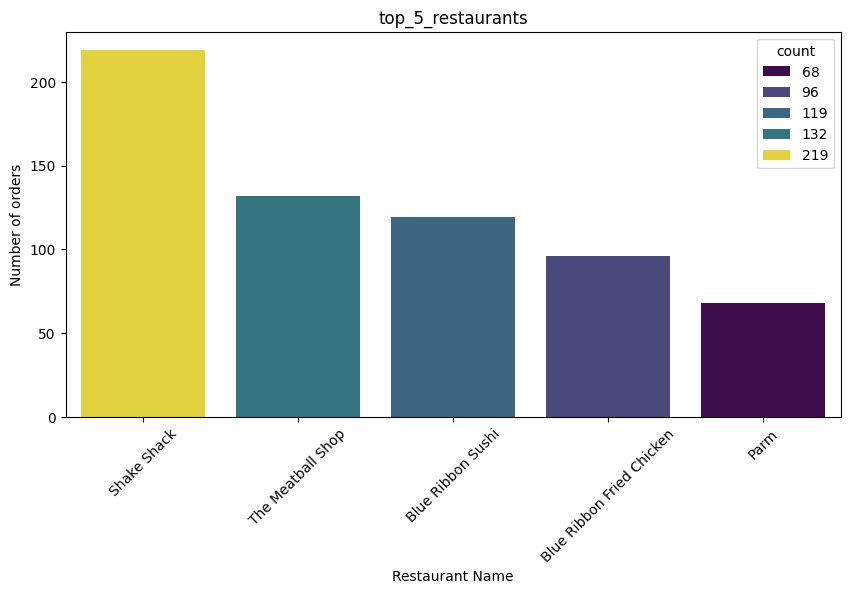

In [26]:
#Plotting the top 5 restaurants serving the orders
plt.figure(figsize=(10,5))
sns.barplot(x=top_5_restaurants.index, y = top_5_restaurants.values, hue = top_5_restaurants,  palette = 'viridis')
plt.title('top_5_restaurants')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of orders')
plt.xticks(rotation=45, fontsize=10)

#### Observations:
Among all the restaurants in the dataset, Shake Shack stands out as the top-performing restaurant, with 219 orders.
The top 5 restaurants has a significant share of the total orders, indicating a concentration of demand for these popular restaurants and the dishes they offer to their customers. These insights can guide the business to further promote and partner with these top restaurants for potential campaigns or offers.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [27]:
# Identifying the popular cusine among the available values
weekend_orders = df[df['day_of_the_week'] == 'Weekend']
popular_cuisine = weekend_orders['cuisine_type'].value_counts().idxmax()
max_count = weekend_orders['cuisine_type'].value_counts().max()

print("The most popular cuisine on weekends is ",popular_cuisine, "with a maximum number of orders: ",max_count)

The most popular cuisine on weekends is  American with a maximum number of orders:  415


([0, 1, 2, 3, 4],
 [Text(0, 0, 'American'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Italian'),
  Text(3, 0, 'Chinese'),
  Text(4, 0, 'Mexican')])

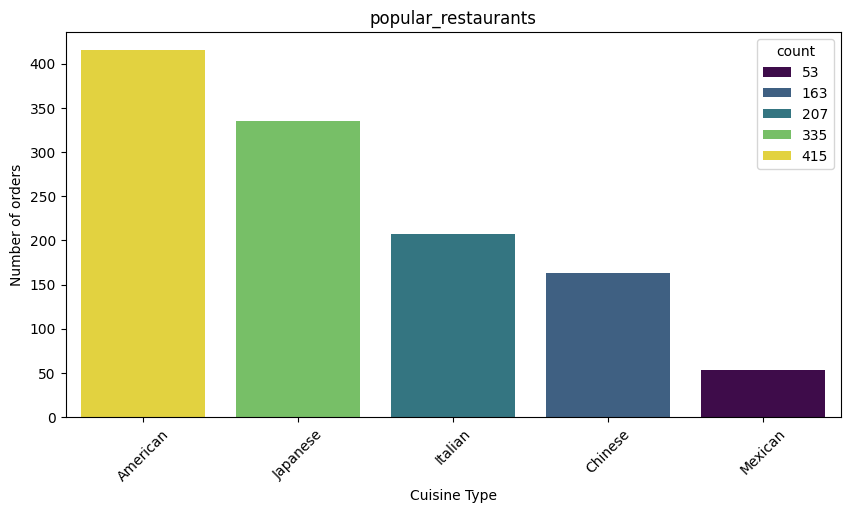

In [21]:
#Plotting the cuisnie types among the popular restaurants serving the orders
popular_restaurants = weekend_orders['cuisine_type'].value_counts().head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=popular_restaurants.index, y = popular_restaurants.values, hue= popular_restaurants, palette = 'viridis')
plt.title('popular_restaurants')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of orders')
plt.xticks(rotation=45, fontsize=10)

#### Observations: Among all the cuisines, the american was most popular during the weekends. Naturally, the type of dishes in american cuisines and its preparartion time would have favoured more compared to others. May be the drive through option or quick processing and delivery options would have benefitted the business.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [28]:
# The total  number of orders in the provided dataset
total_orders = df.shape[0]
print("The total  number of orders:",total_orders)

The total  number of orders: 1898


In [29]:
#Identify the orders that cost more than 20 dollars
above_twenty = df[df['cost_of_the_order'] > 20].shape[0]
print("The total number of orders, that cost more than 20 dollars:",above_twenty)

The total number of orders, that cost more than 20 dollars: 555


In [30]:
#calculate the percentage of orders more than 20 Dollars
percentage = (above_twenty / total_orders) * 100
print("The percentage of the orders cost more than 20 dollars is : ",round(percentage,1),"%")

The percentage of the orders cost more than 20 dollars is :  29.2 %


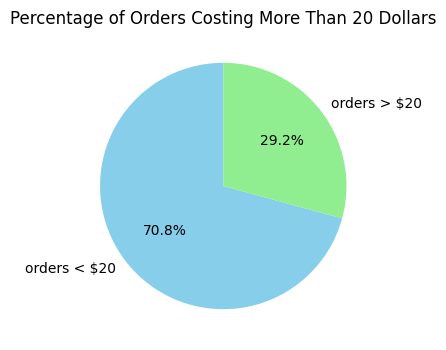

In [64]:
#Pieplot - for cost_of_the_order more than twenty dollars
labels = ['orders < $20','orders > $20']
values = [total_orders-above_twenty, above_twenty]
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(4,4))
plt.pie(values, labels=labels, autopct= '%1.1f%%',startangle=90, colors=colors)
plt.title('Percentage of Orders Costing More Than 20 Dollars')
plt.show()

#### Observations:Out of 1898 orders placed, only 29 % were more than 20 dollars. This suggests, the customers are more likely to order the items with less price. This appears the businesses targeted to process items with less quantity which are quick to process and are also proportional to lesser prices. This helps in attracting the customers to order again.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [31]:
# Calculating the mean on delivery time, to find the average time taken to deliver an order
mean_delivery_time = df['delivery_time'].mean()
print("The average time taken to deliver the order is : ",round(mean_delivery_time,0),"minutes")
print("This metric helps the business to understand, how quickly deliveries are completed on average. ")

The average time taken to deliver the order is :  24.0 minutes
This metric helps the business to understand, how quickly deliveries are completed on average. 


#### Observations:This metric helps the business to understand, how quickly deliveries are completed on average.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [32]:
#Get the individual order counts of the top 3 customers
customer_order_counts = df['customer_id'].value_counts().head(3)
print("The top 3 most frequent customers are : ")
print(customer_order_counts)

The top 3 most frequent customers are : 
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


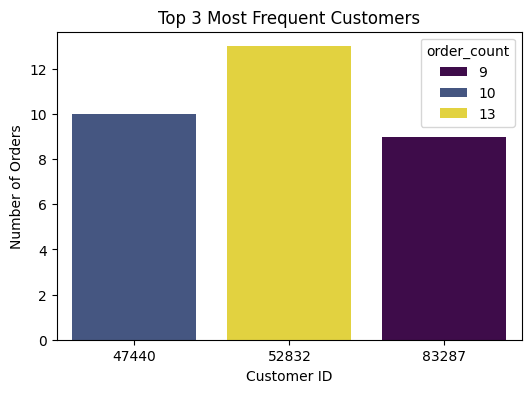

In [33]:
#ploting the top 3 customers
top_3_customers = customer_order_counts.head(3).reset_index()
top_3_customers.columns = ['customer_id', 'order_count']

plt.figure(figsize=(6,4))
sns.barplot(x='customer_id', y='order_count', data=top_3_customers, hue = 'order_count', palette='viridis')
plt.title('Top 3 Most Frequent Customers')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.show()

#### Observations: As observed, the customers with customer_id (52832), (47440), (83287) with (13), (10) and (09) respectively, has placed the most of the orders. Providing them with 20% discount vouchers can strengthen loyalty, encourage repeat business, and potentially boost revenue through continued high-volume ordering behavior.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


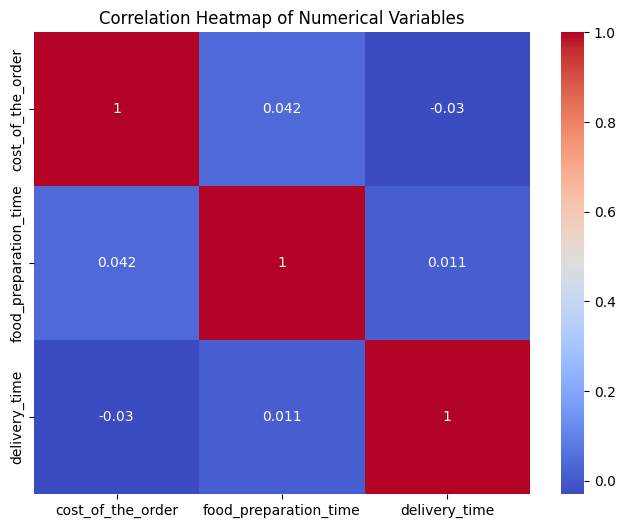

In [34]:
#Creating the heat map to identify the correlations
plt.figure(figsize=(8,6))
sns.heatmap(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

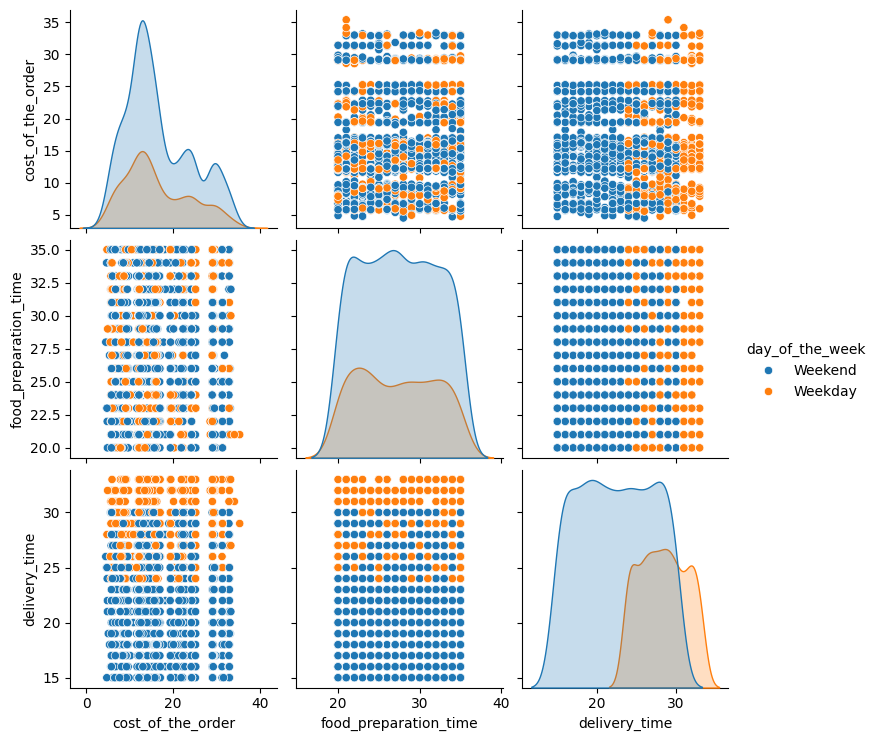

In [35]:
#pair plot the order cost and food preparation time and delivery time
sns.pairplot(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'day_of_the_week']], hue='day_of_the_week')
plt.show()

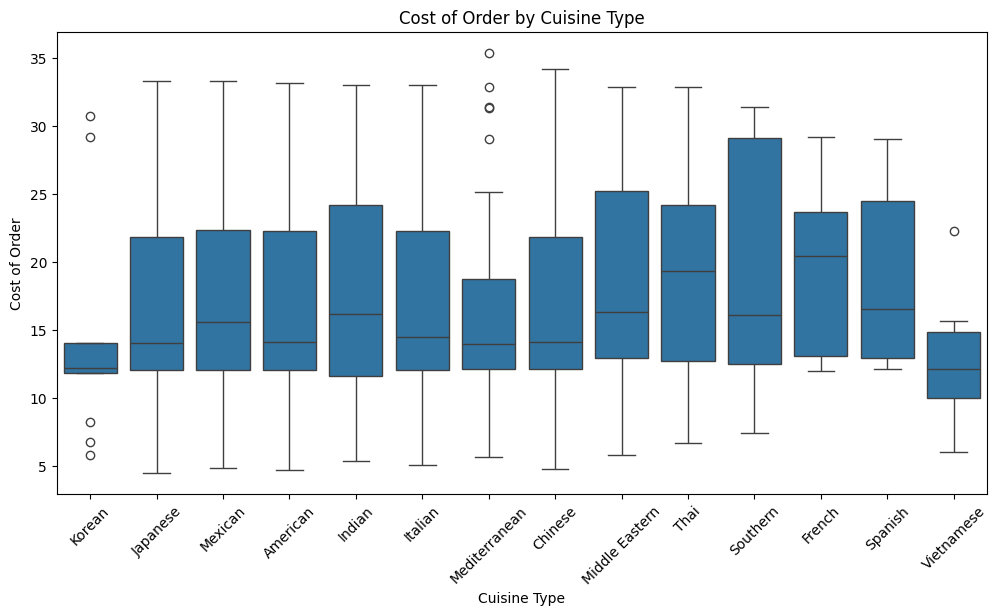

In [36]:
plt.figure(figsize=(12,6))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title('Cost of Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of Order')
plt.xticks(rotation=45)
plt.show()


#### Observations:
Heat Map
1. The correlation between order cost, food preparation time, and delivery time is very low, indicating that these three factors do not strongly influence each other directly. This suggests that restaurants can focus separately on optimizing costs, preparation time, and delivery time without worrying about a trade-off between these metrics.

Pairplot
2. The pairplot visualizes the relationships between cost, preparation time, and delivery time, separated by day of the week. The plots show that most data points cluster around lower costs and shorter preparation and delivery times, regardless of the day. This suggests consistent performance across weekdays and weekends.

Boxplot
3. The boxplot of order cost across different cuisine types shows significant variation. Some cuisines (e.g., Mediterranean, Middle Eastern) have higher average order costs, while others (like Korean and Japanese) have lower costs. This insight can guide targeted pricing and marketing strategies, focusing on high-margin cuisines and optimizing menu design for lower-cost cuisines.


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [119]:
# Convert ratings to numeric, non-numeric to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by restaurant and calculate count and mean of numeric ratings
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()

# Filter based on eligible criteria
eligible_restaurants = restaurant_ratings[(restaurant_ratings['count'] > 50) & (restaurant_ratings['mean'] > 4)]

print("Restaurants eligible for promotional offer:")
print(eligible_restaurants)

Restaurants eligible for promotional offer:
               restaurant_name  count      mean
20   Blue Ribbon Fried Chicken     64  4.328125
21           Blue Ribbon Sushi     73  4.219178
136                Shake Shack    133  4.278195
153          The Meatball Shop     84  4.511905


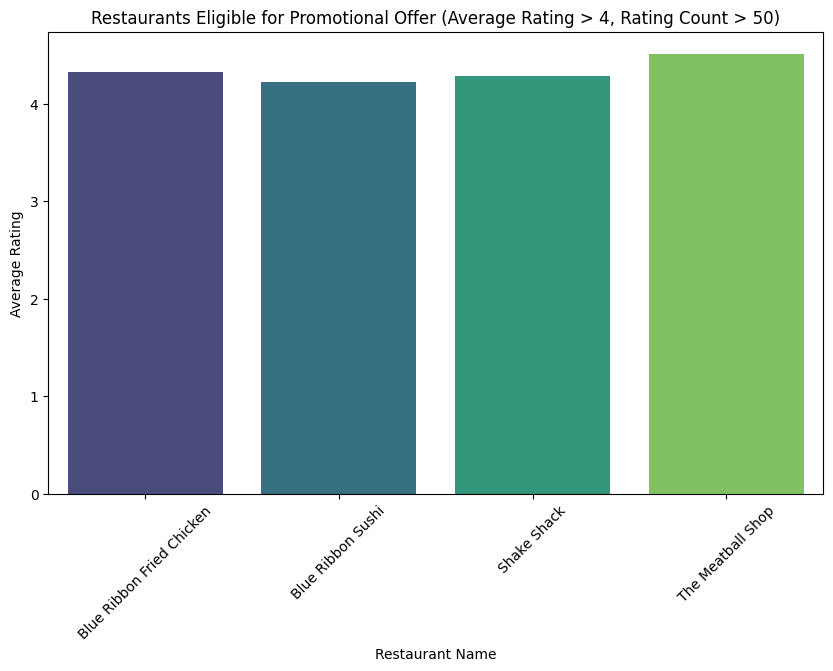

In [120]:
#Visualizing the eligible restaurant with promotional offer
plt.figure(figsize=(10,6))
sns.barplot(x='restaurant_name', y='mean', data=eligible_restaurants, hue = 'restaurant_name', palette='viridis')
plt.title('Restaurants Eligible for Promotional Offer (Average Rating > 4, Rating Count > 50)')
plt.xlabel('Restaurant Name')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

#### Observations:
Grouping the data by the column  restaurant_name provides the count and average customer ratings. The Restaurants with more than 50 ratings and an average rating above 4 are considered eligible for the promotional offer.
These restaurants are likely to have high customer satisfaction and engagement, making them ideal for promotional partnerships. The Meatball Shop outperformed compared to all other restaurants.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [122]:
# Calculate commission for each order directly
commission = np.where(df['cost_of_the_order'] > 20, df['cost_of_the_order'] * 0.25,np.where(df['cost_of_the_order'] > 5, df['cost_of_the_order'] * 0.15, 0))

# Calculate net revenue
net_revenue = commission.sum()

print("The net revenue generated by the company across all orders is: $", round(net_revenue, 2))

The net revenue generated by the company across all orders is: $ 6166.3


#### Observations:
The net revenue generated by the company across all orders is $6166.3 dollars.  

This revenue comes from commissions of 15% and 25% on orders costing more than
5 and 20 dollars respectively.
Probably, the company could consider strategies to encourage more high-value orders to further boost this revenue stream.



### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [137]:
# Calculate total time for each order (no new column added to df!)
total_time = df['food_preparation_time'] + df['delivery_time']

# Count orders with total time > 60
orders_above_60min = (total_time > 60).sum()
print("Number of orders_above_60min:",orders_above_60min)


Number of orders_above_60min: 200


In [138]:
# Calculate the percentage
percentage_above_60 = (orders_above_60min / df.shape[0]) * 100

print("The percentage of orders that take more than 60 minutes to get delivered is: {:.2f}%".format(percentage_above_60))

The percentage of orders that take more than 60 minutes to get delivered is: 10.54%


#### Observations:
The total delivery time is calculated for each order, by summing up food preparation time and delivery time. 10.54% of orders took more than 60 minutes to deliver, indicating some potential delays or inefficiencies in these orders.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [140]:
# To calculate the mean delivery time for weekdays and weekends
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()

print("Mean delivery time for weekdays and weekends:")
print(mean_delivery_time_by_day)

Mean delivery time for weekdays and weekends:
day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


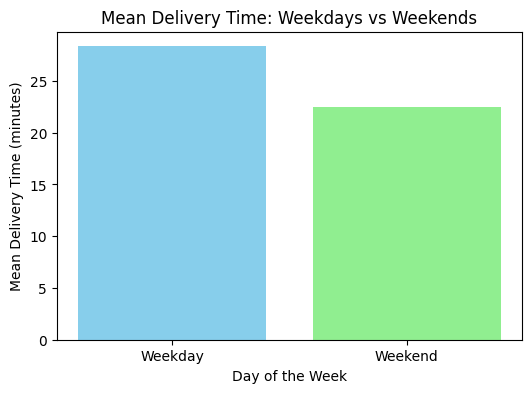

In [141]:
# Create the bar plot for Mean Delivery Time
plt.figure(figsize=(6,4))
plt.bar(mean_delivery_time_by_day.index, mean_delivery_time_by_day.values, color=['skyblue', 'lightgreen'])
plt.title('Mean Delivery Time: Weekdays vs Weekends')
plt.xlabel('Day of the Week')
plt.ylabel('Mean Delivery Time (minutes)')
plt.show()

#### Observations:
As observed, during the weekdays, the delivery time is 28 minutes, whereas the delivery time during the weekends is 22 minutes. This is probably due to the less traffic and some of the customers may have preferred to eat in home.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1.Order Cost & Popularity:
Most orders cost below $20, showing that customers are price-conscious and prefer affordable meals.

Popular restaurants like Shake Shack and certain cuisines (like American, Japanese) dominate orders.
Only 29% of orders cost more than $20, but these orders contribute significantly to revenue.

2.Food Preparation & Delivery Time:
Average food preparation time is 27 minutes, with a range from 20 to 35 minutes.
Mean delivery time is around 24 minutes, showing fairly quick delivery.
10.54% of orders take more than 60 minutes from order to delivery, highlighting potential operational delays.

3.Customer Ratings & Loyalty:
Many orders are not rated (736 orders), limiting feedback for restaurants.
The top 3 most frequent customers placed 13, 10, and 9 orders—indicating loyal customers worth nurturing.
Some restaurants have high average ratings (>4) with enough reviews (>50), making them strong candidates for promotional campaigns.

4.Revenue Generation:
High-value orders (> $20) generate more revenue via 25% commission vs mid-value orders’ 15% commission.
These high-value orders, though fewer in number, drive a large share of the company’s net revenue.

5.Weekday vs Weekend Trends:
Average delivery time varies slightly between weekdays and weekends, showing operational consistency with some room for improvement.

### Recommendations:

1.   Prioritize affordable and popular menu items to cater to the majority of orders under $20.

2.   Identify and address the long preparation and delivery times for faster overall service.
3.   Encourage customer ratings with incentives to gather feedback and improve restaurant performance.
4.   Design promotions for orders over $20 to drive more high-revenue transactions.
5.   Offer loyalty perks to top customers to increase repeat business and retention.
6.   Highlight high-rated restaurants in campaigns to leverage their customer appeal.Analyze cuisine prep times and consider dynamic delivery strategies to optimize performance.






---